In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##🔧 Setup & Khám phá cấu trúc dataset

In [ ]:
# ============================================================
# CELL 1 — Mount Google Drive & kiểm tra cấu trúc thư mục
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

# ✏️ Chỉnh đường dẫn cho đúng với vị trí dataset trong Drive của bạn
# Giả định DATA_ROOT chứa trực tiếp các thư mục lớp (ví dụ: Tomato___Late_blight/)
DATA_ROOT = Path("/content/drive/MyDrive/Data Mining")

# Kiểm tra cấu trúc thư mục con trong DATA_ROOT
print(f"Kiểm tra cấu trúc thư mục tại: {DATA_ROOT}")
found_dirs = [d.name for d in DATA_ROOT.iterdir() if d.is_dir()]
if found_dirs:
    print(f"   Tìm thấy {len(found_dirs)} thư mục lớp: {found_dirs[:5]}{'...' if len(found_dirs)>5 else ''}")
else:
    print("   ❌ Không tìm thấy thư mục con nào. Vui lòng kiểm tra lại đường dẫn DATA_ROOT.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kiểm tra cấu trúc thư mục tại: /content/drive/MyDrive/Data Mining
   Tìm thấy 10 thư mục lớp: ['Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___healthy', 'Tomato___Tomato_mosaic_virus', 'Tomato___Septoria_leaf_spot', 'Tomato___Late_blight']...


# Cài đặt thư viên


In [ ]:
# ============================================================
# CELL 2 — Cài thư viện & import
# ============================================================
!pip install imagehash -q

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import imagehash
from PIL import Image
from scipy.stats import gaussian_kde
from collections import defaultdict
from tqdm.notebook import tqdm

# Cài đặt style đồ thị
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10
})

print("✅ Import hoàn tất!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 15.2 MB/s eta 0:00:00
✅ Import hoàn tất!


# Data frame về tomato


In [ ]:
# ============================================================
# CELL 3 — Build DataFrame index toàn bộ ảnh Tomato
# ============================================================

records = []

# Duyệt qua các thư mục con trong Data Mining
for cls_dir in sorted(DATA_ROOT.iterdir()):
    # Bỏ qua nếu không phải là thư mục hoặc không phải lớp Tomato (nếu bạn chỉ muốn lấy Tomato)
    if not cls_dir.is_dir() or "Tomato" not in cls_dir.name:
        continue

    # Duyệt qua các định dạng ảnh
    for ext in ["*.jpg", "*.JPG", "*.jpeg", "*.png", "*.PNG"]:
        for fp in cls_dir.glob(ext):
            records.append({
                "path": str(fp),
                "label_full": cls_dir.name,
                "split": "all"  # Gán mặc định vì cấu trúc của bạn không chia train/valid ở bước này
            })

df = pd.DataFrame(records)

# Rút gọn tên lớp: bỏ tiền tố "Tomato___" hoặc "Tomato_"
if len(df) > 0:
    df["label"] = (df["label_full"]
                   .str.replace("Tomato___", "", regex=False)
                   .str.replace("Tomato_", "", regex=False)
                   .str.replace("_", " "))

    print(f"✅ Tổng ảnh Tomato: {len(df):,}")
    print(f"\nPhân bố theo split:")
    print(df["split"].value_counts().to_string())
    print(f"\nDanh sách lớp ({df['label'].nunique()} lớp):")
    print(df["label"].value_counts().to_string())
else:
    print("❌ Không tìm thấy ảnh nào. Vui lòng kiểm tra lại đường dẫn DATA_ROOT.")

✅ Tổng ảnh Tomato: 16,931

Phân bố theo split:
split
all    16931

Danh sách lớp (10 lớp):
label
Yellow Leaf Curl Virus                  1961
healthy                                 1926
Leaf Mold                               1882
Late blight                             1851
Target Spot                             1827
mosaic virus                            1790
Septoria leaf spot                      1745
Spider mites Two-spotted spider mite    1741
Bacterial spot                          1702
Early blight                             506


# A. Phân phối pixel (Histogram + KDE)
- Mục đích là để xem phân phối màu của ảnh trong từng lớp.
- Dựa vào đó sẽ có một số trường hợp cần điều chỉnh khi xảy ra:
  - **Trường hợp 1: Kênh R >> G, B (ảnh bị lệch đỏ)** -> Cân bằng màu bằng histogram equalization hoặc dùng CLAHE ( dùng tốt cho lá cây).
  - **Trường hợp 2: Mean pixel < 50 (ảnh quá tối) hoặc > 200 (quá sáng)** -> Normalize về cùng dải [0, 1] hoặc chuẩn hóa Z-score theo mean/std của DATASET.
  - **Trường hợp 3: Kênh G cao hơn hẳn (bình thường với ảnh lá cây)** -> Không cần xử lý — đây là đặc điểm tự nhiên của lá xanh.

## 1. Lấy mẫu pixel ngẫu nhiên từ toàn tập


In [ ]:
# ============================================================
# CELL 4 — Lấy mẫu pixel ngẫu nhiên từ toàn tập
# ============================================================
# Không đọc hết ~87k ảnh → sample đại diện
SAMPLE_N       = 600    # số ảnh lấy mẫu
PIXELS_PER_IMG = 800    # số pixel ngẫu nhiên mỗi ảnh

np.random.seed(42)
sample_df = df.sample(min(SAMPLE_N, len(df)), random_state=42)

channels = {"R": [], "G": [], "B": []}
failed = 0

for fp in tqdm(sample_df["path"], desc="📖 Đọc pixel"):
    img = cv2.imread(fp)
    if img is None:
        failed += 1
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape
    ys = np.random.randint(0, h, PIXELS_PER_IMG)
    xs = np.random.randint(0, w, PIXELS_PER_IMG)
    pixels = img_rgb[ys, xs]                    # (PIXELS_PER_IMG, 3)
    channels["R"].extend(pixels[:, 0].tolist())
    channels["G"].extend(pixels[:, 1].tolist())
    channels["B"].extend(pixels[:, 2].tolist())

channels = {k: np.array(v) for k, v in channels.items()}
print(f"✅ Lấy mẫu xong | Tổng pixel/kênh: {len(channels['R']):,} | Lỗi đọc: {failed}")

# In thống kê nhanh
for ch, vals in channels.items():
    print(f"  Kênh {ch}: mean={vals.mean():.1f}  std={vals.std():.1f}  "
          f"min={vals.min()}  max={vals.max()}")

📖 Đọc pixel:   0%|          | 0/600 [00:00<?, ?it/s]

✅ Lấy mẫu xong | Tổng pixel/kênh: 480,000 | Lỗi đọc: 0
  Kênh R: mean=120.7  std=54.4  min=0  max=255
  Kênh G: mean=124.2  std=49.9  min=0  max=255
  Kênh B: mean=112.8  std=57.8  min=0  max=255


## 2. Histogram + KDE từng kênh (3 subplot riêng)

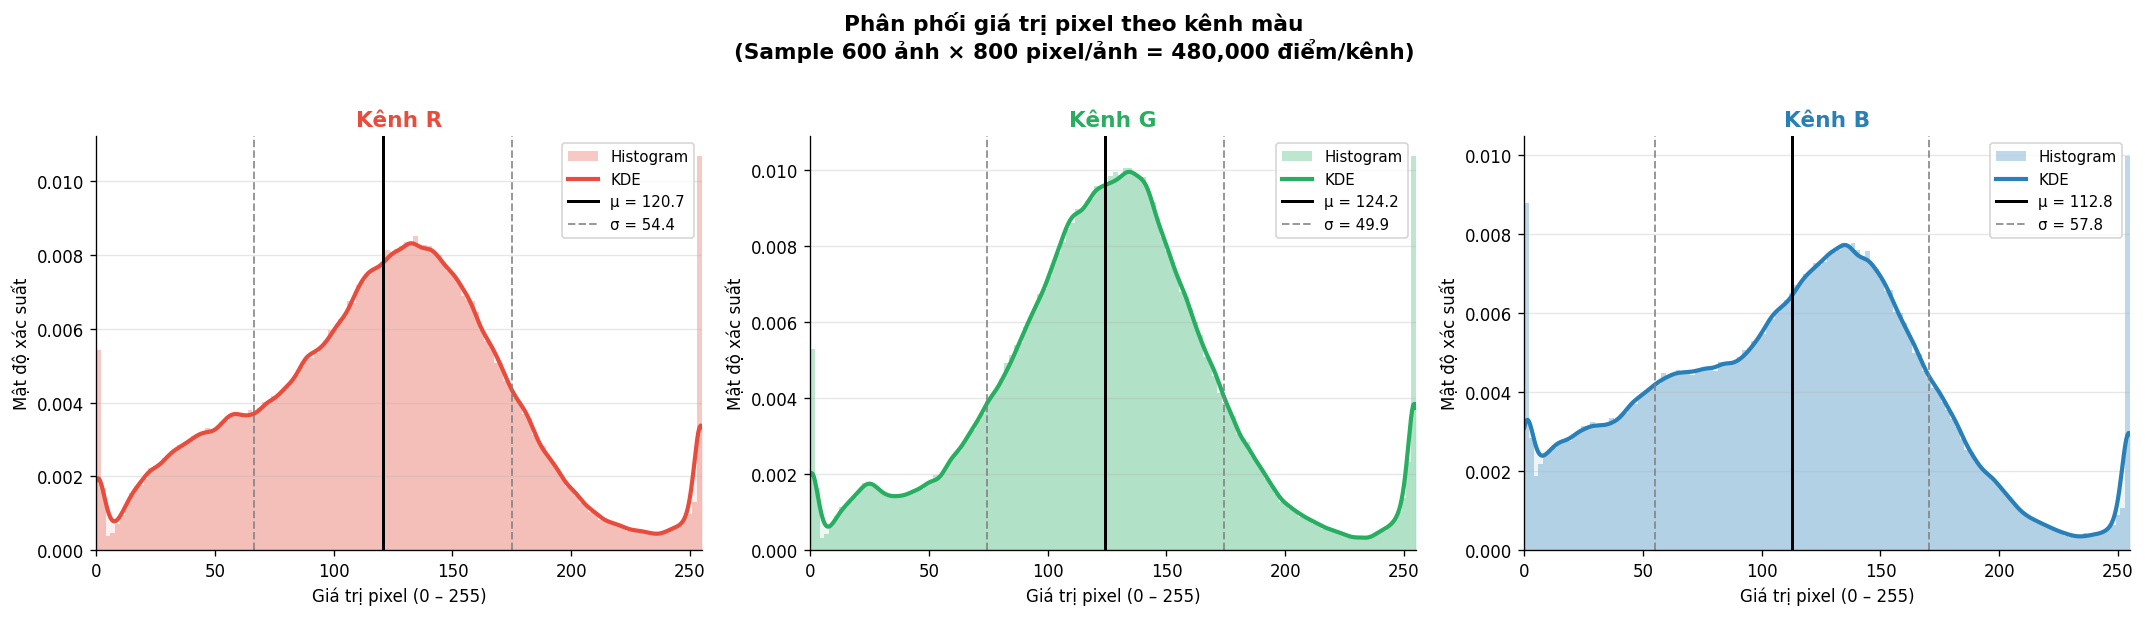

💾 Lưu: a1_pixel_histogram_kde.png


In [ ]:
# ============================================================
# CELL 5 — Histogram + KDE từng kênh (3 subplot riêng)
# ============================================================
COLOR_HEX = {"R": "#e74c3c", "G": "#27ae60", "B": "#2980b9"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f"Phân phối giá trị pixel theo kênh màu\n"
    f"(Sample {SAMPLE_N} ảnh × {PIXELS_PER_IMG} pixel/ảnh = {len(channels['R']):,} điểm/kênh)",
    fontsize=13, fontweight="bold", y=1.02
)

for ax, (ch, color) in zip(axes, COLOR_HEX.items()):
    vals = channels[ch]

    # --- Histogram (mật độ) ---
    ax.hist(vals, bins=128, range=(0, 255),
            color=color, alpha=0.30, density=True, label="Histogram")

    # --- KDE ---
    # Downsample để KDE tính nhanh hơn
    kde_vals = vals[::5]
    kde = gaussian_kde(kde_vals, bw_method=0.05)
    x = np.linspace(0, 255, 512)
    ax.plot(x, kde(x), color=color, linewidth=2.5, label="KDE")
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

    # --- Đường mean & ±1σ ---
    mu, sigma = vals.mean(), vals.std()
    ax.axvline(mu, color="black", linestyle="-",
               linewidth=1.8, label=f"μ = {mu:.1f}")
    ax.axvline(mu - sigma, color="gray", linestyle="--",
               linewidth=1.2, alpha=0.8)
    ax.axvline(mu + sigma, color="gray", linestyle="--",
               linewidth=1.2, alpha=0.8, label=f"σ = {sigma:.1f}")

    ax.set_title(f"Kênh {ch}", fontsize=13, color=color, fontweight="bold")
    ax.set_xlabel("Giá trị pixel (0 – 255)")
    ax.set_ylabel("Mật độ xác suất")
    ax.set_xlim(0, 255)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("a1_pixel_histogram_kde.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Lưu: a1_pixel_histogram_kde.png")

## 3. KDE chồng 3 kênh + nhận xét tự động

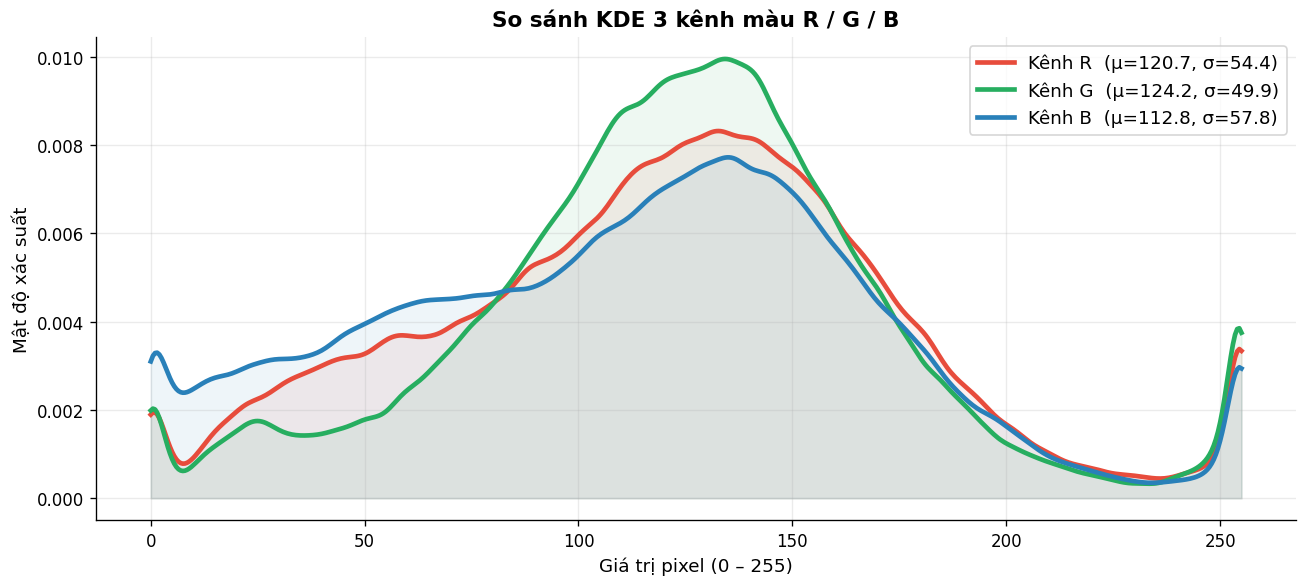


📝 Nhận xét tự động:
  Kênh R: μ=120.7, σ=54.4 → phân phối cân đối
  Kênh G: μ=124.2, σ=49.9 → phân phối cân đối
  Kênh B: μ=112.8, σ=57.8 → phân phối cân đối
  → Kênh G có giá trị trung bình cao nhất (ảnh thiên về màu này)


In [ ]:
# ============================================================
# CELL 6 — KDE chồng 3 kênh + nhận xét tự động
# ============================================================
fig, ax = plt.subplots(figsize=(11, 5))
ax.set_title("So sánh KDE 3 kênh màu R / G / B", fontsize=13, fontweight="bold")

for ch, color in COLOR_HEX.items():
    vals = channels[ch]
    kde = gaussian_kde(vals[::5], bw_method=0.05)
    x = np.linspace(0, 255, 512)
    ax.plot(x, kde(x), color=color, linewidth=2.8,
            label=f"Kênh {ch}  (μ={vals.mean():.1f}, σ={vals.std():.1f})")
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

ax.set_xlabel("Giá trị pixel (0 – 255)", fontsize=11)
ax.set_ylabel("Mật độ xác suất", fontsize=11)
ax.legend(fontsize=11)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("a2_pixel_kde_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Nhận xét tự động ---
dominant = max(COLOR_HEX, key=lambda c: channels[c].mean())
print("\n📝 Nhận xét tự động:")
for ch in ["R", "G", "B"]:
    v = channels[ch]
    skew = "lệch phải" if v.mean() > 127 else "lệch trái" if v.mean() < 100 else "cân đối"
    print(f"  Kênh {ch}: μ={v.mean():.1f}, σ={v.std():.1f} → phân phối {skew}")
print(f"  → Kênh {dominant} có giá trị trung bình cao nhất (ảnh thiên về màu này)")

# B. Mất cân bằng lớp (Class Imbalance)
Làm để:
- Giả sử dataset có:
- Lớp "Healthy": 3000 ảnh
- Lớp "Early Blight": 200 ảnh

Nếu train bình thường, model sẽ **lười biếng** — nó học cách đoán "Healthy" cho mọi ảnh vì đúng 93% lần. Lớp bệnh hiếm sẽ bị bỏ qua hoàn toàn, dù đó là lớp quan trọng nhất trong thực tế.

Nếu xảy ra vấn đề (theo giả sử):
- **Phương pháp 1: Class Weights (đơn giản nhất)** -> Với ý tưởng: phạt model nặng hơn khi sai ở lớp ít ảnh
- **Phương pháp 2: Oversampling lớp thiểu số** -> Với ý tưởng: nhân bản ảnh ở lớp ít để bằng lớp nhiều nhất
- **Phương pháp 3: Augmentation lớp thiểu số** -> Với ý tưởng: TẠO THÊM ảnh mới bằng cách biến đổi ngẫu nhiên

In [ ]:
# ============================================================
# CELL 7 — Tính tỉ lệ từng lớp & kiểm tra ngưỡng 3×
# ============================================================
# Phân tích trên tập TRAIN (đại diện cho dữ liệu học)
# Cần kiểm tra lại nếu dataset có split train/valid rõ ràng.
# Hiện tại, df chỉ có split 'all', nên sẽ phân tích trên toàn bộ df.
# df_train = df[df["split"] == "train"].copy() # Dòng này gây lỗi nếu không có split 'train'
df_train = df[df["split"] == "all"].copy() # Sử dụng 'all' split để phân tích toàn bộ dữ liệu hiện có
total_train = len(df_train)

# Đảm bảo df_train không trống trước khi tiếp tục
if total_train == 0:
    print("❌ Không tìm thấy ảnh trong tập 'train' (hoặc 'all' nếu đã đổi). Vui lòng kiểm tra lại cột 'split' trong df.")
else:
    class_counts = (
        df_train["label"]
        .value_counts()
        .reset_index()
        .rename(columns={"index": "label", "label": "label", "count": "count"})
    )
    # Tương thích cả pandas cũ và mới
    class_counts.columns = ["label", "count"]
    class_counts["ratio_%"] = (class_counts["count"] / total_train * 100).round(2)

    min_count = class_counts["count"].min()
    max_count = class_counts["count"].max()
    imb_ratio = max_count / min_count
    threshold = 3 * min_count

    class_counts["vuot_nguong"] = class_counts["count"] > threshold

    print("=" * 62)
    print(f"{'Lớp':<38} {'Số ảnh':>7}  {'Tỉ lệ':>7}  {'Cảnh báo'}")
    print("=" * 62)
    for _, row in class_counts.iterrows():
        flag = "⚠️  VƯỢT 3×" if row["vuot_nguong"] else "✅"
        print(f"{row['label']:<38} {row['count']:>7}  {row['ratio_%']:>6.2f}%  {flag}")

    print("=" * 62)
    print(
        f"\n📌 Lớp ít nhất  : {class_counts.loc[class_counts['count'].idxmin(), 'label']}"
        f" ({min_count} ảnh)"
    )
    print(
        f"📌 Lớp nhiều nhất: {class_counts.loc[class_counts['count'].idxmax(), 'label']}"
        f" ({max_count} ảnh)"
    )
    print(f"📌 Imbalance ratio (max/min): {imb_ratio:.2f}×  |  Ngưỡng cảnh báo: 3.00×")

    if imb_ratio > 3:
        bad = class_counts[class_counts["vuot_nguong"]]["label"].tolist()
        print(f"\n⚠️  KẾT LUẬN: Có {len(bad)} lớp vượt ngưỡng 3×:")
        for b in bad:
            print(f"   • {b}")
        print("   → Cần xem xét oversampling / class weights khi huấn luyện!")
    else:
        print("\n✅ KẾT LUẬN: Không có lớp nào vượt ngưỡng 3× — dataset tương đối cân bằng.")

Lớp                                     Số ảnh    Tỉ lệ  Cảnh báo
Yellow Leaf Curl Virus                    1961   11.58%  ⚠️  VƯỢT 3×
healthy                                   1926   11.38%  ⚠️  VƯỢT 3×
Leaf Mold                                 1882   11.12%  ⚠️  VƯỢT 3×
Late blight                               1851   10.93%  ⚠️  VƯỢT 3×
Target Spot                               1827   10.79%  ⚠️  VƯỢT 3×
mosaic virus                              1790   10.57%  ⚠️  VƯỢT 3×
Septoria leaf spot                        1745   10.31%  ⚠️  VƯỢT 3×
Spider mites Two-spotted spider mite      1741   10.28%  ⚠️  VƯỢT 3×
Bacterial spot                            1702   10.05%  ⚠️  VƯỢT 3×
Early blight                               506    2.99%  ✅

📌 Lớp ít nhất  : Early blight (506 ảnh)
📌 Lớp nhiều nhất: Yellow Leaf Curl Virus (1961 ảnh)
📌 Imbalance ratio (max/min): 3.88×  |  Ngưỡng cảnh báo: 3.00×

⚠️  KẾT LUẬN: Có 9 lớp vượt ngưỡng 3×:
   • Yellow Leaf Curl Virus
   • healthy
   • Leaf Mold
   

## Biểu đồ cột nằm ngang + Pie chart
- Để giúp trực quan hoá dữ liệu lên.

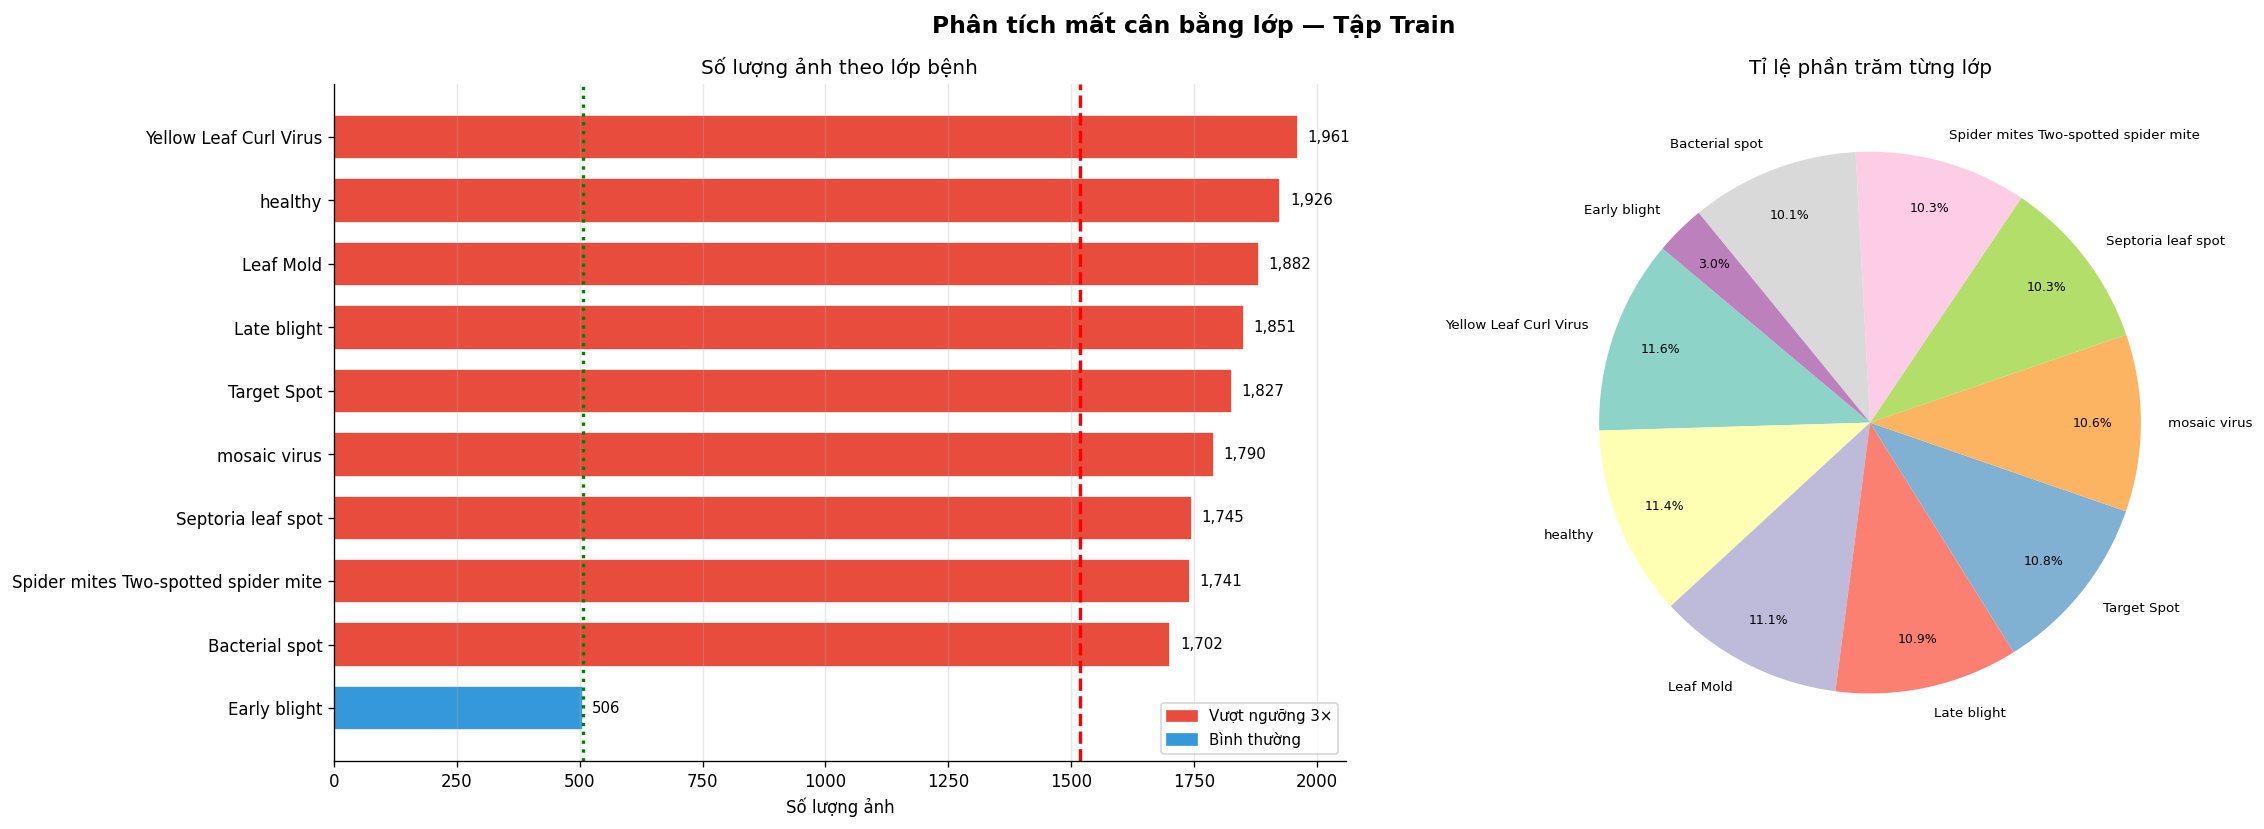

💾 Lưu: b_class_imbalance.png


In [ ]:
# ============================================================
# CELL 8 — Biểu đồ cột nằm ngang + Pie chart
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("Phân tích mất cân bằng lớp — Tập Train",
             fontsize=14, fontweight="bold")

order = class_counts.sort_values("count")

# ── Màu: đỏ nếu vượt ngưỡng, xanh nếu bình thường ──
bar_colors = ["#e74c3c" if v else "#3498db" for v in order["vuot_nguong"]]

# --- Bar chart nằm ngang ---
ax1 = axes[0]
bars = ax1.barh(order["label"], order["count"],
                color=bar_colors, edgecolor="white", height=0.7)

# Nhãn số trên bar
for bar in bars:
    w = bar.get_width()
    ax1.text(w + order["count"].max() * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f"{int(w):,}", va="center", fontsize=9)

# Đường ngưỡng
ax1.axvline(threshold, color="red", linestyle="--",
            linewidth=2, label=f"Ngưỡng 3× ({threshold:,})")
ax1.axvline(min_count, color="green", linestyle=":",
            linewidth=2, label=f"Lớp nhỏ nhất ({min_count:,})")

# Legend màu
p1 = mpatches.Patch(color="#e74c3c", label="Vượt ngưỡng 3×")
p2 = mpatches.Patch(color="#3498db", label="Bình thường")
ax1.legend(handles=[p1, p2], loc="lower right", fontsize=9)

ax1.set_xlabel("Số lượng ảnh")
ax1.set_title("Số lượng ảnh theo lớp bệnh", fontsize=12)
ax1.grid(axis="x", alpha=0.3)

# --- Pie chart ---
ax2 = axes[1]
pie_colors = plt.cm.Set3.colors[:len(class_counts)]
wedges, texts, autotexts = ax2.pie(
    class_counts["count"],
    labels=class_counts["label"],
    autopct="%1.1f%%",
    startangle=140,
    colors=pie_colors,
    pctdistance=0.82
)
for t in texts:
    t.set_fontsize(8)
for at in autotexts:
    at.set_fontsize(7.5)
ax2.set_title("Tỉ lệ phần trăm từng lớp", fontsize=12)

plt.tight_layout()
plt.savefig("b_class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Lưu: b_class_imbalance.png")

# C. Phát hiện ảnh trùng lặp (pHash)
**Lý do kiểm tra**: Nếu cùng một ảnh xuất hiện ở cả **train lẫn validation set**, bạn đang "gian lận" — model được test trên ảnh nó đã thấy khi học. Kết quả accuracy sẽ cao giả tạo, nhưng khi dùng thực tế thì tệ.

Cách pHash hoạt động:

- Ảnh gốc (256×256)

       ↓ resize xuống 32×32 (bỏ chi tiết nhỏ, giữ cấu trúc)
       ↓ chuyển grayscale
       ↓ áp dụng DCT (Discrete Cosine Transform) — giống nén JPEG
       ↓ lấy 64 bit quan trọng nhất
       → Ra chuỗi 64-bit = "dấu vân tay" của ảnh

=> So sánh 2 ảnh = đếm số bit khác nhau = Hamming Distance

  - Distance = 0   → y chang nhau (exact duplicate)
  - Distance 1–10  → gần giống (near-duplicate, có thể resize/crop nhẹ)
  - Distance > 10  → ảnh khác nhau

  **Nếu kết quả có vấn đề**:
  - Xóa exact duplicate, giữ lại 1 bản
  - Xử lý near-duplicate: kiểm tra cross-class:
    - Near-duplicate CÙNG lớp → xóa 1 bản (an toàn)
    - Near-duplicate KHÁC lớp → NGUY HIỂM → cần review thủ công
  - Kiểm tra data leakage train/valid: Tìm ảnh trùng giữa train và valid

## 1. Tính pHash cho toàn bộ ảnh

In [ ]:
# ============================================================
# CELL 9 — Tính pHash cho toàn bộ ảnh
# ============================================================
# pHash tính trên ảnh grayscale 32×32 → rất nhanh
HASH_SIZE  = 8      # pHash dùng (8×8)² = 64 bit
HASH_THRESH = 10    # Hamming distance tối đa → near-duplicate

hash_list = []

for fp in tqdm(df["path"], desc="🔢 Tính pHash"):
    try:
        img_pil = Image.open(fp).convert("RGB")
        ph      = imagehash.phash(img_pil, hash_size=HASH_SIZE)
        hash_list.append({"path": fp,
                          "label": df.loc[df["path"] == fp, "label"].values[0],
                          "split": df.loc[df["path"] == fp, "split"].values[0],
                          "phash_str": str(ph),
                          "phash_obj": ph})
    except Exception:
        hash_list.append({"path": fp, "label": "?", "split": "?",
                          "phash_str": None, "phash_obj": None})

df_hash = pd.DataFrame(hash_list)
valid_hash = df_hash[df_hash["phash_str"].notna()].reset_index(drop=True)
print(f"✅ Tính hash xong: {len(valid_hash)}/{len(df_hash)} ảnh hợp lệ")

🔢 Tính pHash:   0%|          | 0/16931 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 2. Tìm exact duplicate (cùng hash)

In [ ]:
# ============================================================
# CELL 10 — Tìm exact duplicate (cùng hash)
# ============================================================
exact_groups = (valid_hash
                .groupby("phash_str")["path"]
                .apply(list)
                .reset_index())
exact_groups.columns = ["phash_str", "paths"]
exact_dup_groups = exact_groups[exact_groups["paths"].apply(len) > 1]

# Ảnh thừa = tổng ảnh trong nhóm dup - 1 đại diện mỗi nhóm
n_exact_groups = len(exact_dup_groups)
n_exact_imgs   = sum(len(g) - 1 for g in exact_dup_groups["paths"])

print(f"📌 Exact duplicates:")
print(f"   Số nhóm trùng    : {n_exact_groups}")
print(f"   Số ảnh cần xóa   : {n_exact_imgs}")

# Danh sách path cần xóa (giữ ảnh đầu tiên mỗi nhóm)
exact_to_remove = set()
for paths in exact_dup_groups["paths"]:
    exact_to_remove.update(paths[1:])

## 3. Tìm near-duplicate (Hamming distance ≤ threshold)

In [ ]:
# ============================================================
# CELL 11 — Tìm near-duplicate (Hamming distance ≤ threshold)
# ============================================================
# Với ~87k ảnh, O(n²) quá chậm → sample tập train
# Chiến lược: so sánh trong từng lớp (intra-class) + cross-class

COMPARE_LIMIT = 2000   # tăng nếu runtime cho phép
np.random.seed(42)

sample_idx = np.random.choice(len(valid_hash),
                               min(COMPARE_LIMIT, len(valid_hash)),
                               replace=False)
sample_h   = valid_hash.iloc[sample_idx].reset_index(drop=True)

hash_objs  = sample_h["phash_obj"].tolist()
paths_s    = sample_h["path"].tolist()
labels_s   = sample_h["label"].tolist()

near_dup_pairs = []

for i in tqdm(range(len(hash_objs)), desc="🔍 So sánh hash"):
    for j in range(i + 1, len(hash_objs)):
        dist = hash_objs[i] - hash_objs[j]
        if 0 < dist <= HASH_THRESH:
            near_dup_pairs.append({
                "path_A": paths_s[i],
                "path_B": paths_s[j],
                "label_A": labels_s[i],
                "label_B": labels_s[j],
                "hamming": dist,
                "cross_class": labels_s[i] != labels_s[j]
            })

df_near = pd.DataFrame(near_dup_pairs) if near_dup_pairs else pd.DataFrame()
print(f"\n📌 Near-duplicates (dist ≤ {HASH_THRESH}) trong {COMPARE_LIMIT} ảnh mẫu:")
print(f"   Số cặp tìm thấy  : {len(df_near)}")
if len(df_near) > 0:
    cross = df_near["cross_class"].sum()
    print(f"   Cùng lớp         : {len(df_near) - cross}")
    print(f"   Khác lớp (⚠️)   : {cross}  ← nguy hiểm nhất!")
    print(f"\n   Phân bố Hamming distance:")
    print(df_near["hamming"].value_counts().sort_index().to_string())

## 4. Báo cáo tổng hợp & xử lý

In [ ]:
# ============================================================
# CELL 12 — Báo cáo tổng hợp & xử lý
# ============================================================
total = len(df)
dup_exact_rate  = n_exact_imgs / total * 100
near_rate       = len(df_near) / COMPARE_LIMIT * 100 if len(df_near) > 0 else 0

print("╔══════════════════════════════════════════╗")
print("║     BÁO CÁO TRÙNG LẶP ẢNH (pHash)       ║")
print("╠══════════════════════════════════════════╣")
print(f"║  Tổng ảnh              : {total:>7,}         ║")
print(f"║  Exact duplicates      : {n_exact_imgs:>7,}  ({dup_exact_rate:.2f}%)  ║")
print(f"║  Near-dup (trong mẫu)  : {len(df_near):>7,}  ({near_rate:.2f}%)  ║")
print("╠══════════════════════════════════════════╣")
print("║  XỬ LÝ:                                  ║")
print("║  • Exact dup → xóa bản sao, giữ 1 ảnh   ║")
print("║  • Near-dup  → review thủ công hoặc xóa  ║")
print("╚══════════════════════════════════════════╝")

# Tạo df_clean loại bỏ exact duplicate
df_clean = df[~df["path"].isin(exact_to_remove)].reset_index(drop=True)
print(f"\n✅ df_clean: {len(df)} → {len(df_clean)} ảnh "
      f"(đã loại {len(exact_to_remove)} exact duplicate)")

## 5. Trực quan hóa: phân bố Hamming + ví dụ cặp trùng

In [ ]:
# ============================================================
# CELL 13 — Trực quan hóa: phân bố Hamming + ví dụ cặp trùng
# ============================================================
fig = plt.figure(figsize=(18, 10))
fig.suptitle("Phân tích ảnh trùng lặp (pHash)", fontsize=14, fontweight="bold")

# --- Sub 1: Histogram Hamming distance ---
ax1 = fig.add_subplot(3, 4, (1, 2)) # Changed 2 to 3 for nrows
if len(df_near) > 0:
    ax1.bar(df_near["hamming"].value_counts().sort_index().index,
            df_near["hamming"].value_counts().sort_index().values,
            color="#9b59b6", edgecolor="white")
    ax1.set_xlabel("Hamming Distance")
    ax1.set_ylabel("Số cặp")
    ax1.set_title(f"Phân bố Hamming Distance (≤{HASH_THRESH})")
    ax1.grid(axis="y", alpha=0.3)
else:
    ax1.text(0.5, 0.5, "Không có near-duplicate\ntrong mẫu",
             ha="center", va="center", fontsize=12)
    ax1.axis("off")

# --- Sub 2: Bar exact dup theo lớp ---
ax2 = fig.add_subplot(3, 4, (3, 4)) # Changed 2 to 3 for nrows
dup_labels = []
for paths in exact_dup_groups["paths"]:
    for p in paths[1:]:
        match = df[df["path"] == p]["label"]
        if len(match) > 0:
            dup_labels.append(match.values[0])

if dup_labels:
    dup_by_class = pd.Series(dup_labels).value_counts()
    dup_by_class.plot(kind="bar", ax=ax2, color="#e67e22", edgecolor="white")
    ax2.set_title("Số exact duplicate theo lớp")
    ax2.set_xlabel("")
    ax2.set_ylabel("Số ảnh duplicate")
    ax2.tick_params(axis="x", rotation=45)
    ax2.grid(axis="y", alpha=0.3)
else:
    ax2.text(0.5, 0.5, "Không có exact duplicate", ha="center", va="center")
    ax2.axis("off")

# --- Sub 3-8: Ví dụ cặp near-dup ---
n_examples = min(3, len(df_near))
for i, (_, row) in enumerate(df_near.head(n_examples).iterrows()):
    for j, (fp_key, col_off) in enumerate([("path_A", 0), ("path_B", 1)]):
        ax = fig.add_subplot(3, 4, 5 + i * 2 + j) # Changed 2 to 3 for nrows
        img = cv2.imread(row[fp_key])
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        side = "A" if j == 0 else "B"
        ax.set_title(f"Cặp {i+1}{side}  dist={row['hamming']}\n"
                     f"{row['label_A' if j==0 else 'label_B'][:25]}",
                     fontsize=7)
        ax.axis("off")

plt.tight_layout()
plt.savefig("c_duplicate_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Lưu: c_duplicate_analysis.png")

# D. Độ sáng & Độ tương phản
** Lý do làm**: Model CNN học bằng cách so sánh các ảnh với nhau. Nếu lớp "Healthy" toàn ảnh sáng chụp ngoài nắng, còn lớp "Late Blight" toàn ảnh tối chụp trong nhà — model có thể học cách phân biệt **ánh sáng** thay vì **triệu chứng bệnh thật sự**. Đây gọi là **spurious correlation** (tương quan giả).

**Xử lý vấn đề**:
- Chuẩn hóa độ sáng bằng CLAHE
- Lọc ảnh ngoại lai về độ sáng/tương phản -> Ảnh quá tối, quá sáng, hoặc gần như đồng màu → loại bỏ
- Chuẩn hóa Z-score theo từng lớp

## 1. Tính mean & std intensity toàn bộ ảnh

In [ ]:
# ============================================================
# CELL 14 — Tính mean & std intensity toàn bộ ảnh
# ============================================================
# Dùng df_clean (đã loại duplicate), resize 64×64 để nhanh

brightness_records = []

for _, row in tqdm(df_clean.iterrows(), total=len(df_clean),
                   desc="☀️ Tính brightness/contrast"):
    img = cv2.imread(row["path"])
    if img is None:
        continue
    # Grayscale → mean = độ sáng, std = độ tương phản
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    small = cv2.resize(gray, (64, 64))

    brightness_records.append({
        "label": row["label"],
        "split": row["split"],
        "mean_intensity": float(small.mean()),
        "std_intensity":  float(small.std()),
        "path": row["path"]
    })

df_bright = pd.DataFrame(brightness_records)

# Thống kê tổng hợp theo lớp
summary = df_bright.groupby("label").agg(
    n          = ("mean_intensity", "count"),
    mean_bright= ("mean_intensity", "mean"),
    std_bright = ("mean_intensity", "std"),
    med_bright = ("mean_intensity", "median"),
    mean_contr = ("std_intensity",  "mean"),
    std_contr  = ("std_intensity",  "std"),
    med_contr  = ("std_intensity",  "median"),
).round(2)

print("📋 Bảng thống kê Mean Intensity & Std Intensity theo lớp:\n")
print(summary.to_string())

## 2. Boxplot Mean Intensity & Std Intensity theo lớp

In [ ]:
# ============================================================
# CELL 15 — Boxplot Mean Intensity & Std Intensity theo lớp
# ============================================================
# Sắp xếp theo median để dễ đọc
order_bright = (df_bright.groupby("label")["mean_intensity"]
                .median().sort_values().index.tolist())
order_contr  = (df_bright.groupby("label")["std_intensity"]
                .median().sort_values().index.tolist())

palette = sns.color_palette("Set2", n_colors=df_bright["label"].nunique())

fig, axes = plt.subplots(2, 1, figsize=(16, 14))
fig.suptitle("Phân tích Độ sáng & Độ tương phản theo lớp bệnh Tomato",
             fontsize=14, fontweight="bold")

# ── Strip plot sample (tránh quá nhiều điểm) ──
sample_strip = df_bright.sample(min(3000, len(df_bright)), random_state=42)

# --- Boxplot 1: Mean Intensity ---
ax1 = axes[0]
sns.boxplot(data=df_bright, x="label", y="mean_intensity",
            order=order_bright, palette=palette, ax=ax1,
            flierprops=dict(marker=".", markersize=2, alpha=0.3))
sns.stripplot(data=sample_strip, x="label", y="mean_intensity",
              order=order_bright, color="black",
              alpha=0.12, size=2, ax=ax1, jitter=True)

global_mean_b = df_bright["mean_intensity"].mean()
ax1.axhline(global_mean_b, color="red", linestyle="--",
            linewidth=1.8, label=f"Global mean = {global_mean_b:.1f}")
ax1.set_title("Mean Intensity theo lớp  (độ sáng trung bình)", fontsize=12)
ax1.set_ylabel("Mean pixel value (0–255)")
ax1.set_xlabel("")
ax1.tick_params(axis="x", rotation=40)
ax1.legend(fontsize=10)
ax1.grid(axis="y", alpha=0.3)

# --- Boxplot 2: Std Intensity ---
ax2 = axes[1]
sns.boxplot(data=df_bright, x="label", y="std_intensity",
            order=order_contr, palette=palette, ax=ax2,
            flierprops=dict(marker=".", markersize=2, alpha=0.3))
sns.stripplot(data=sample_strip, x="label", y="std_intensity",
              order=order_contr, color="black",
              alpha=0.12, size=2, ax=ax2, jitter=True)

global_mean_c = df_bright["std_intensity"].mean()
ax2.axhline(global_mean_c, color="red", linestyle="--",
            linewidth=1.8, label=f"Global mean = {global_mean_c:.1f}")
ax2.set_title("Std Intensity theo lớp  (độ tương phản)", fontsize=12)
ax2.set_ylabel("Std pixel value")
ax2.set_xlabel("")
ax2.tick_params(axis="x", rotation=40)
ax2.legend(fontsize=10)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("d1_brightness_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Lưu: d1_brightness_boxplot.png")

## 3. Heatmap tổng hợp & Scatter mean vs std

In [ ]:
# ============================================================
# CELL 16 — Heatmap tổng hợp & Scatter mean vs std
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Tổng hợp độ sáng & tương phản theo lớp",
             fontsize=13, fontweight="bold")

# --- Heatmap ---
ax1 = axes[0]
heat_df = summary[["mean_bright", "med_bright", "mean_contr", "med_contr"]].copy()
heat_df.columns = ["Mean\nBrightness", "Median\nBrightness",
                   "Mean\nContrast", "Median\nContrast"]
sns.heatmap(heat_df, annot=True, fmt=".1f", cmap="RdYlGn",
            linewidths=0.5, ax=ax1,
            cbar_kws={"label": "Pixel value"})
ax1.set_title("Heatmap: Độ sáng & Tương phản trung bình", fontsize=12)
ax1.set_ylabel("")

# --- Scatter: mean_intensity vs std_intensity ---
ax2 = axes[1]
label_list = df_bright["label"].unique()
colors_sc  = plt.cm.Set2(np.linspace(0, 1, len(label_list)))

for lbl, col in zip(label_list, colors_sc):
    subset = df_bright[df_bright["label"] == lbl]
    ax2.scatter(subset["mean_intensity"], subset["std_intensity"],
                alpha=0.15, s=8, color=col, label=lbl)

# Centroid mỗi lớp
for lbl, col in zip(label_list, colors_sc):
    subset = df_bright[df_bright["label"] == lbl]
    ax2.scatter(subset["mean_intensity"].mean(),
                subset["std_intensity"].mean(),
                color=col, s=120, marker="*",
                edgecolors="black", linewidth=0.8, zorder=5)

ax2.set_xlabel("Mean Intensity (độ sáng)", fontsize=11)
ax2.set_ylabel("Std Intensity (độ tương phản)", fontsize=11)
ax2.set_title("Scatter: Sáng vs Tương phản (★ = centroid lớp)", fontsize=12)
ax2.legend(fontsize=7, loc="upper left",
           ncol=2, framealpha=0.8)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("d2_brightness_scatter_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Lưu: d2_brightness_scatter_heatmap.png")

## 4. Nhận xét tự động phần d

In [ ]:
# ============================================================
# CELL 17 — Nhận xét tự động phần d
# ============================================================
brightest = summary["mean_bright"].idxmax()
darkest   = summary["mean_bright"].idxmin()
most_contr= summary["mean_contr"].idxmax()
least_contr=summary["mean_contr"].idxmin()

print("=" * 55)
print("📝 NHẬN XÉT TỰ ĐỘNG — Độ sáng & Tương phản")
print("=" * 55)
print(f"☀️  Lớp sáng nhất  : {brightest}")
print(f"    mean = {summary.loc[brightest, 'mean_bright']:.1f}")
print(f"🌑  Lớp tối nhất   : {darkest}")
print(f"    mean = {summary.loc[darkest, 'mean_bright']:.1f}")
print(f"📈  Tương phản cao : {most_contr}")
print(f"    std  = {summary.loc[most_contr, 'mean_contr']:.1f}")
print(f"📉  Tương phản thấp: {least_contr}")
print(f"    std  = {summary.loc[least_contr, 'mean_contr']:.1f}")
print("=" * 55)
print("\n💡 Gợi ý tiền xử lý:")
print("  • Lớp có mean_intensity quá thấp → cân nhắc tăng sáng (CLAHE)")
print("  • Lớp có std thấp → ảnh đồng đều, ít chi tiết → augment contrast")
print("  • Độ lệch lớn giữa các lớp → cần normalize trước khi train")